In [102]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [103]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

In [104]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error,mean_squared_error,r2_score

In [105]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score,confusion_matrix,classification_report
from sklearn.metrics import ConfusionMatrixDisplay

In [106]:
df = pd.read_csv("a1 ml 2 data.csv")
print(df.head())

   customerID  gender  SeniorCitizen Partner Dependents  tenure PhoneService  \
0  7590-VHVEG  Female              0     Yes         No       1           No   
1  5575-GNVDE    Male              0      No         No      34          Yes   
2  3668-QPYBK    Male              0      No         No       2          Yes   
3  7795-CFOCW    Male              0      No         No      45           No   
4  9237-HQITU  Female              0      No         No       2          Yes   

      MultipleLines InternetService OnlineSecurity  ... DeviceProtection  \
0  No phone service             DSL             No  ...               No   
1                No             DSL            Yes  ...              Yes   
2                No             DSL            Yes  ...               No   
3  No phone service             DSL            Yes  ...              Yes   
4                No     Fiber optic             No  ...               No   

  TechSupport StreamingTV StreamingMovies        Contract Pape

In [114]:
df['TotalCharges'] = df['TotalCharges'].replace(' ',np.nan)
df['TotalCharges']=pd.to_numeric(df['TotalCharges'],errors='coerce').fillna(0)

df['SeniorCitizen'] = df['SeniorCitizen'].astype(str)

df['ChurnTarget']=df['Churn'].apply(lambda x: 1 if x=='Yes' else 0)

In [115]:
df["TotalCharges"]=pd.to_numeric(df["TotalCharges"],errors="coerce")

In [116]:
df.dropna(inplace=True)

In [118]:
df["Churn"]=df["Churn"].map({"Yes":1,"No":0})

In [119]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 22 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   object 
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


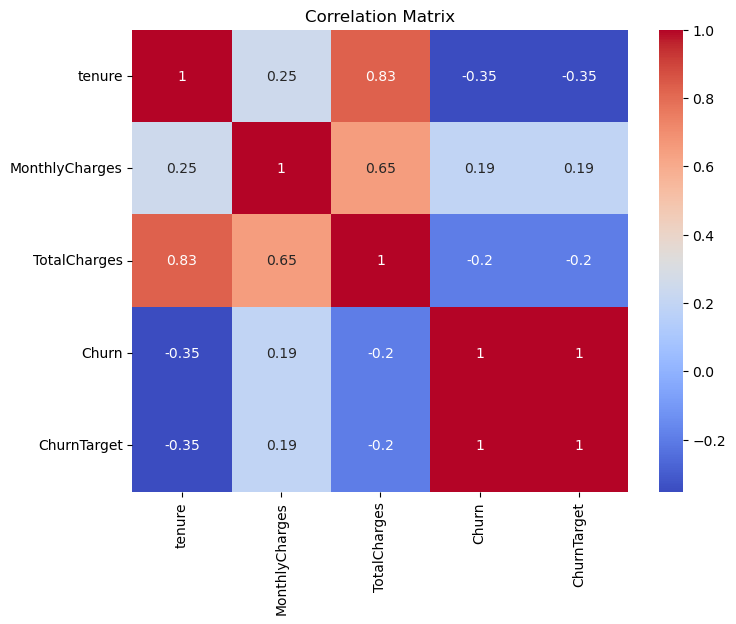

In [121]:
numeric_df = df.select_dtypes(include='number')

plt.figure(figsize=(8,6))
sns.heatmap(numeric_df.corr(), annot=True,cmap="coolwarm")
plt.title("Correlation Matrix")
plt.show()

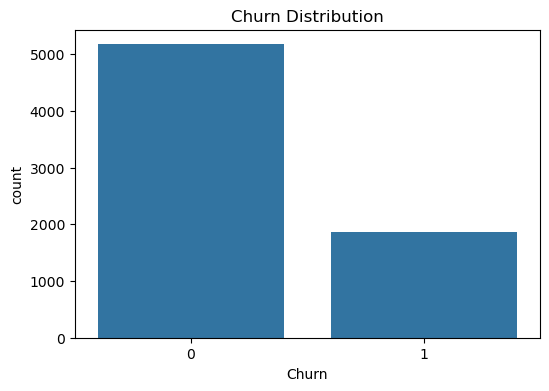

In [122]:
plt.figure(figsize=(6,4))
sns.countplot(x="Churn", data=df)
plt.title("Churn Distribution")
plt.show()

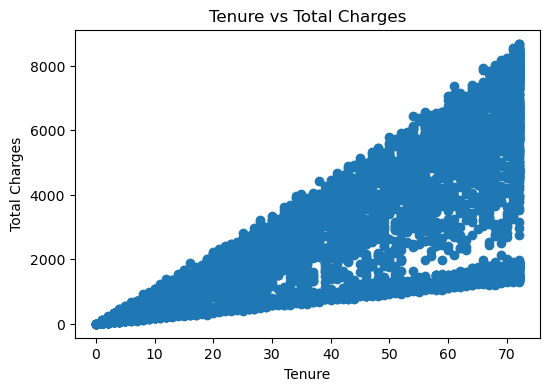

In [123]:
plt.figure(figsize=(6,4))
plt.scatter(df["tenure"], df["TotalCharges"])
plt.xlabel("Tenure")
plt.ylabel("Total Charges")
plt.title("Tenure vs Total Charges")
plt.show()

In [124]:
x=df[["tenure","MonthlyCharges"]]
y=df["TotalCharges"]

In [125]:
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42)

In [128]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [129]:
model = LinearRegression()
model.fit(X_train,y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [130]:
y_pred=model.predict(X_test)

print("Predicted Values:")
print(y_pred[:10])

Predicted Values:
[-1199.12334134  1440.04239626  1950.9853583    639.32672622
  4047.35347322  5505.5885347   2110.57192967  5143.79014366
  6150.29785642 -1391.70588964]


In [131]:
mae=mean_absolute_error(y_test, y_pred)
mse=mean_squared_error(y_test, y_pred)
rmse=np.sqrt(mse)
r2=r2_score(y_test, y_pred)

print("Mean Absolute Error:",mae)
print("Mean Squared Error:",mse)
print("Root Mean Squared Error:",rmse)
print("R2 Score:",r2)

Mean Absolute Error: 603.6207086431045
Mean Squared Error: 571100.5266578791
Root Mean Squared Error: 755.7119336479205
R2 Score: 0.8902238820918934


In [132]:
!pip install dython

In [133]:
from dython.nominal import associations

['tenure', 'Churn']
['InternetService', 'OnlineSecurity', 'TechSupport', 'Contract', 'PaymentMethod']


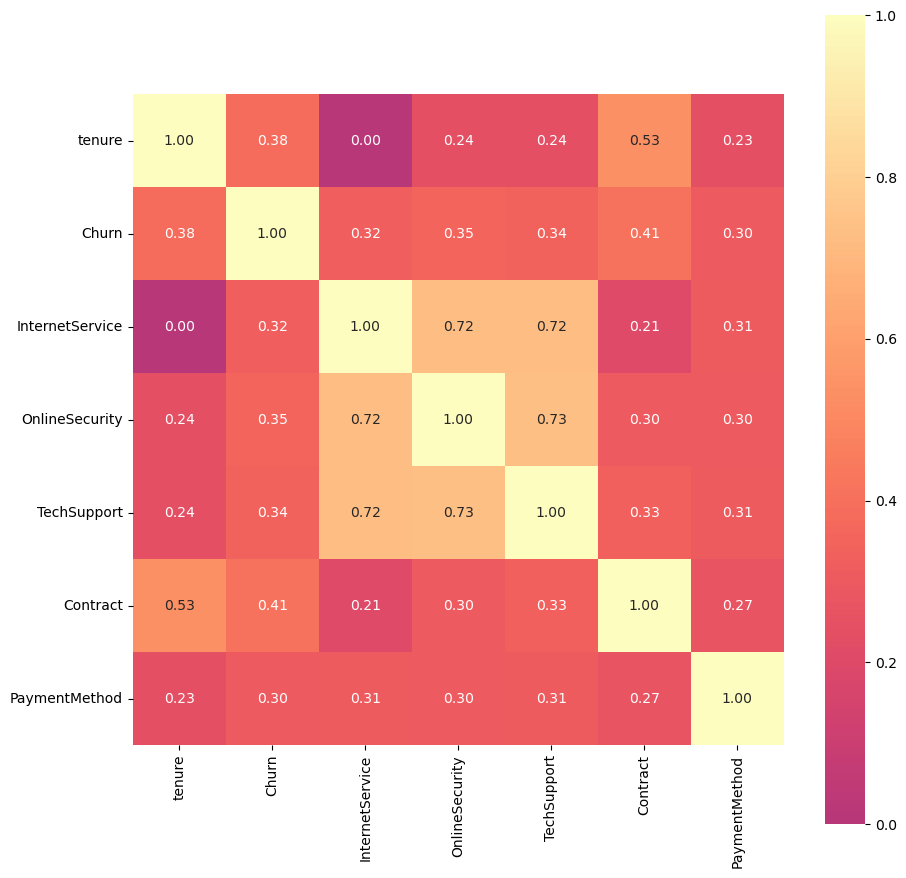

{'corr':                    tenure     Churn  InternetService  OnlineSecurity  \
 tenure           1.000000  0.375575         0.000000        0.241694   
 Churn            0.375575  1.000000         0.322037        0.347016   
 InternetService  0.000000  0.322037         1.000000        0.724373   
 OnlineSecurity   0.241694  0.347016         0.724373        1.000000   
 TechSupport      0.240824  0.342526         0.722811        0.732982   
 Contract         0.532743  0.409798         0.206263        0.300920   
 PaymentMethod    0.234853  0.302677         0.312486        0.304303   
 
                  TechSupport  Contract  PaymentMethod  
 tenure              0.240824  0.532743       0.234853  
 Churn               0.342526  0.409798       0.302677  
 InternetService     0.722811  0.206263       0.312486  
 OnlineSecurity      0.732982  0.300920       0.304303  
 TechSupport         1.000000  0.330639       0.306237  
 Contract            0.330639  1.000000       0.265892  
 Paymen

In [135]:
import numpy as np
import pandas as pd
from dython.nominal import associations

target = 'ChurnTarget'

num_features = df.select_dtypes(include=[np.number]).columns.drop(target, errors='ignore')
correlations = df[num_features].corrwith(df[target])
selected_num_features = correlations[abs(correlations) > 0.3].index.tolist()

cat_features = df.drop(['customerID', 'address'], axis=1, errors='ignore').select_dtypes(include=['object','category']).columns.tolist()

if target in df.columns and target not in cat_features:
    cat_features.append(target)
    
assoc = associations(df[cat_features], nominal_columns='all', plot=False)
corr_matrix = assoc['corr']
selected_cat_features = corr_matrix.loc[target][corr_matrix.loc[target] > 0.3].index.tolist()
selected_cat_features=[col for col in selected_cat_features if col != target]

print(selected_num_features)
print(selected_cat_features)

selected_features = selected_num_features + selected_cat_features

associations(df[selected_features], nominal_columns='all',cmap='magma')

In [137]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report
from sklearn.model_selection import train_test_split

X = df[selected_features]
y = df[target]

cat_features = X.select_dtypes(include=['object']).columns.tolist()
num_features = X.select_dtypes(include=['number']).columns.tolist()

X_train_val, X_test, y_train_val, y_test = train_test_split( X, y, test_size=0.2, random_state=42, stratify=y)

X_train, X_val, y_train, y_val = train_test_split(X_train_val, y_train_val,test_size=0.25, random_state=42,stratify=y_train_val)

preprocessor = ColumnTransformer(
    transformers=[('num', 'passthrough', num_features), ('cat', OneHotEncoder(handle_unknown='ignore'), cat_features)])

pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(max_iter=1000))])

pipeline.fit(X_train, y_train)

,steps,"[('preprocessor', ...), ('classifier', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [139]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
y_train_encoded = le.fit_transform(y_train)
y_test_encoded = le.transform(y_test)

models = {
    'Logistic Regression': LogisticRegression(max_iter=1000),
    'Decision Tree': DecisionTreeClassifier(),
    'Random Forest': RandomForestClassifier(),
    'SVM': SVC(),
    'Gradient Boosting': GradientBoostingClassifier(),
    'XGBoost': XGBClassifier(eval_metric='logloss'),
    'LightGBM': LGBMClassifier()
}

results = []

for name, model in models.items():
    pipe = Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('classifier', model)
    ])
    pipe.fit(X_train, y_train_encoded)
    y_pred = pipe.predict(X_test)
    recall = recall_score(y_test_encoded, y_pred)
    
    results.append((name, recall))

results

[LightGBM] [Info] Number of positive: 1121, number of negative: 3104
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000683 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 107
[LightGBM] [Info] Number of data points in the train set: 4225, number of used features: 18
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.265325 -> initscore=-1.018470
[LightGBM] [Info] Start training from score -1.018470
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, b

[('Logistic Regression', 1.0),
 ('Decision Tree', 1.0),
 ('Random Forest', 1.0),
 ('SVM', 0.7807486631016043),
 ('Gradient Boosting', 1.0),
 ('XGBoost', 1.0),
 ('LightGBM', 1.0)]

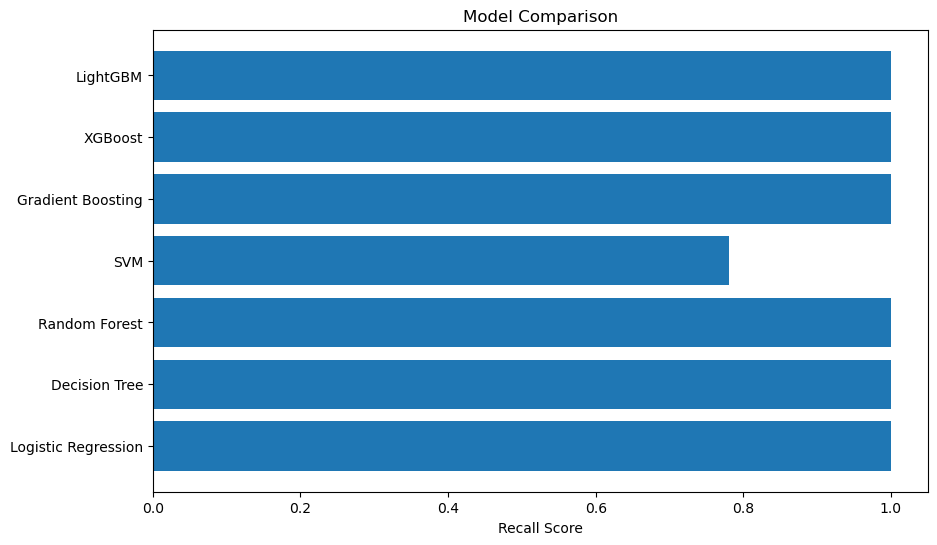

In [140]:
import matplotlib.pyplot as plt

model_names = [r[0] for r in results]
test_recalls = [r[1] for r in results]

plt.figure(figsize=(10, 6))
plt.barh(model_names, test_recalls)
plt.xlabel('Recall Score')
plt.title('Model Comparison')
plt.show()

In [142]:
from sklearn.metrics import classification_report

best_model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', GradientBoostingClassifier())
])

best_model.fit(X_train, y_train)
y_pred = best_model.predict(X_test)

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1035
           1       1.00      1.00      1.00       374

    accuracy                           1.00      1409
   macro avg       1.00      1.00      1.00      1409
weighted avg       1.00      1.00      1.00      1409



In [143]:
import joblib

joblib.dump(best_model, 'churn_model.pkl')

['churn_model.pkl']

In [144]:
loaded_model = joblib.load('churn_model.pkl')

sample_input = X_test.iloc[:1]
prediction = loaded_model.predict(sample_input)
prediction_proba = loaded_model.predict_proba(sample_input)

print("Prediction:", "Churn" if prediction[0] == 1 else "No Churn")
print("Probability of Churn:", round(prediction_proba[0][1], 2))

Prediction: No Churn
Probability of Churn: 0.0


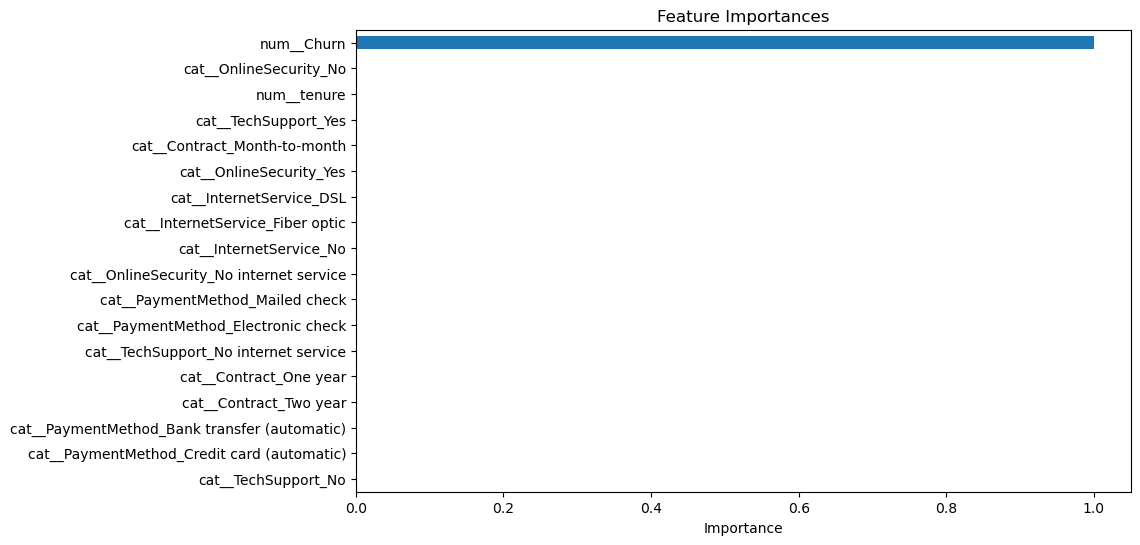

In [146]:
import pandas as pd
import matplotlib.pyplot as plt

feature_names = loaded_model.named_steps['preprocessor'].get_feature_names_out()
importances = loaded_model.named_steps['classifier'].feature_importances_

feat_importances = pd.Series(importances, index=feature_names).sort_values(ascending=True)

plt.figure(figsize=(10, 6))
feat_importances.plot(kind='barh')
plt.title('Feature Importances')
plt.xlabel('Importance')
plt.show()

In [148]:
target = 'ChurnTarget'


X = df.drop(columns=['Churn', 'ChurnTarget', 'customerID'], errors='ignore')
y = df[target]


X = X[[c for c in selected_features if c not in ['Churn', 'ChurnTarget']]]


X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [149]:
cat_features = X.select_dtypes(include=['object', 'category']).columns.tolist()
num_features = X.select_dtypes(include=['number']).columns.tolist()

preprocessor = ColumnTransformer(
    transformers=[
        ('num', 'passthrough', num_features),
        ('cat', OneHotEncoder(handle_unknown='ignore'), cat_features)
    ]
)

best_model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', GradientBoostingClassifier())
])

best_model.fit(X_train, y_train)

,steps,"[('preprocessor', ...), ('classifier', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


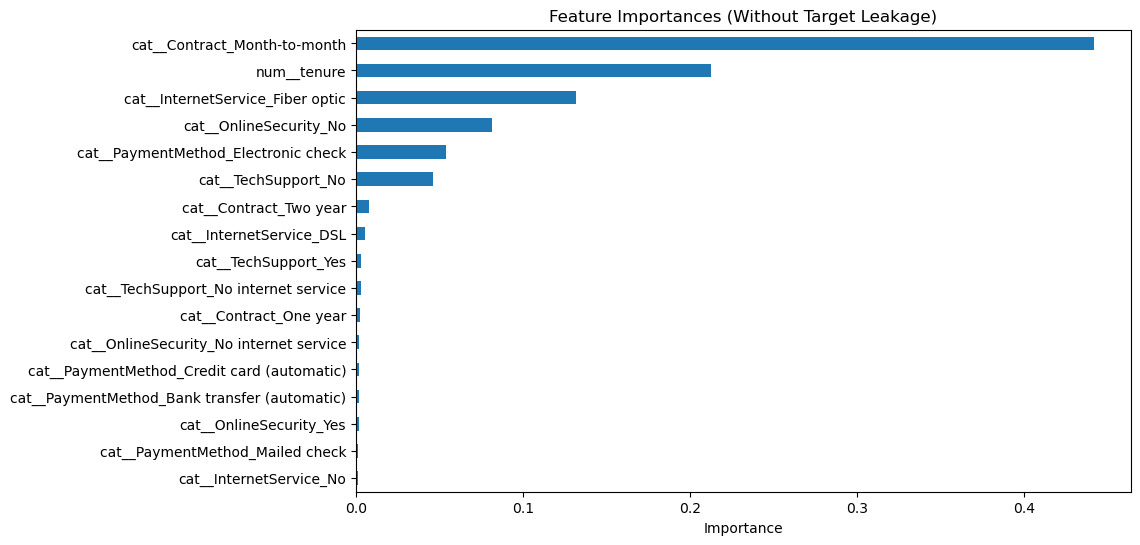

In [150]:
import pandas as pd
import matplotlib.pyplot as plt

feature_names = best_model.named_steps['preprocessor'].get_feature_names_out()
importances = best_model.named_steps['classifier'].feature_importances_

feat_importances = pd.Series(importances, index=feature_names).sort_values(ascending=True)

plt.figure(figsize=(10, 6))
feat_importances.plot(kind='barh')
plt.title('Feature Importances (Without Target Leakage)')
plt.xlabel('Importance')
plt.show()